# Epidemic model SIR 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numba
from scipy import integrate

## Model diagram

The diagram below sums up the model SIR that we studied.

![](https://upload.wikimedia.org/wikipedia/commons/3/30/Diagram_of_SIR_epidemic_model_states_and_transition_rates.svg)


[Source: Wikipedia](https://upload.wikimedia.org/wikipedia/commons/3/30/Diagram_of_SIR_epidemic_model_states_and_transition_rates.svg)

## Problem formulation

In [3]:

np.random.seed(30)

N     = 200
beta  = 0.4    
gamma = 0.04   
i0    = 1

healthy, infected, recovered = N - i0, i0, 0 # Health
t = 0.0
ts = [t]
S = [healthy]
I = [infected]
R = [recovered]


while  infected > 0:
    rate =  np.array([beta*healthy*infected/N, gamma*infected])
    dt = -np.log(np.random.rand(2)) / rate
    event = np.argmin(dt)
    t += dt[event] 
    if event ==0: 
        healthy -= 1
        infected += 1
    else: 
        infected -= 1
        recovered += 1
    ts.append(t)
    S.append(healthy) 
    I.append(infected) 
    R.append(recovered)
     


C:\Users\fedtm\AppData\Local\Temp\ipykernel_10116\934907866.py:18: RuntimeWarning: divide by zero encountered in divide
  dt = -np.log(np.random.rand(2)) / rate


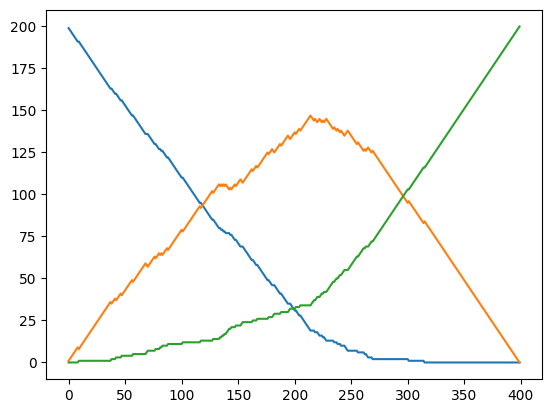

In [4]:
plt.plot(S)
plt.plot(I)
plt.plot(R)

# Recovered can be in effected again +
# Infected can die instead of begin recovered + 
# vaccination acceptation 

C:\Users\fedtm\AppData\Local\Temp\ipykernel_10116\806135407.py:25: RuntimeWarning: divide by zero encountered in divide
  dt = -np.log(np.random.rand(5)) / rate # 0 = infected, 1= recovered, 2 = dø, #3 =  recovered -> suseptible # 4 vacciancted


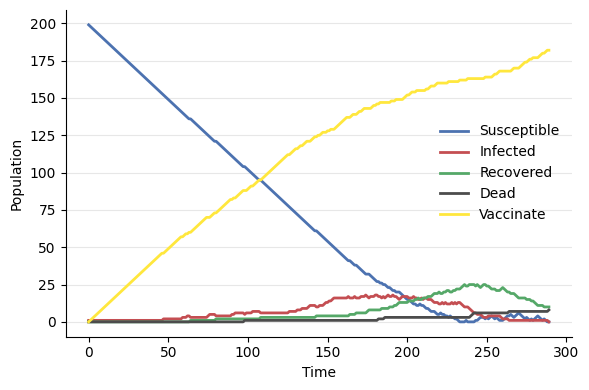

In [5]:

np.random.seed(30)

N     = 200
beta  = 0.4   # rates for infection
gamma = 0.04  # rate for recovery
mu = 0.005 # rate for death
eta = 0.01 # rate for be suseptible again
xi = gamma/beta*0.6

i0    = 1

healthy, infected, recovered,death,vaccinated = N - i0, i0, 0,0,0 # Health
t = 0.0
ts = [t]
S = [healthy]
I = [infected]
R = [recovered]
D = [death]
RV = [vaccinated]


while  infected > 0:
    N = healthy + recovered +infected +vaccinated- death
    rate =  np.array([beta*healthy*infected/N, gamma*infected,mu*infected,eta*recovered,xi*healthy])
    dt = -np.log(np.random.rand(5)) / rate # 0 = infected, 1= recovered, 2 = dø, #3 =  recovered -> suseptible # 4 vacciancted
    event = np.argmin(dt)
    t += dt[event] 
    if event ==0: 
        healthy -= 1
        infected += 1
    if event == 1:
        infected -= 1
        recovered += 1
    if event == 2: 
        infected -= 1
        death += 1
    if event == 3:
        healthy +=1 
        recovered -=1
    if event == 4:
        healthy -=1 
        vaccinated +=1
    ts.append(t)
    S.append(healthy) 
    I.append(infected) 
    R.append(recovered)
    D.append(death)
    RV.append(vaccinated)
     

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(S, color="#4C72B0", lw=2, label="Susceptible")
ax.plot(I, color="#C44E52", lw=2, label="Infected")
ax.plot(R, color="#55A868", lw=2, label="Recovered")
ax.plot(D, color="#4C4C4C", lw=2, label="Dead")
ax.plot(RV, color ="#FFE73D",lw=2, label="Vaccinate")


ax.set_xlabel("Time")
ax.set_ylabel("Population")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("sird.pdf")
plt.show()